In [ ]:
# import libraries for data work, modeling, and plots
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor

# set project folders used throughout the notebook
PROJECT_DIR = Path('..').resolve()
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
RESULTS_DIR = PROJECT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print('Project dir:', PROJECT_DIR)
print('Processed dir:', PROCESSED_DIR)

Project dir: /Users/esamuddin/Documents/UofT/ECE1513/project/Toronto-Bikeshare-Forecasting
Processed dir: /Users/esamuddin/Documents/UofT/ECE1513/project/Toronto-Bikeshare-Forecasting/data/processed


In [8]:
# load the prepared train/validation/test splits
train = pd.read_csv(PROCESSED_DIR / 'train.csv', parse_dates=['hour'])
val = pd.read_csv(PROCESSED_DIR / 'val.csv', parse_dates=['hour'])
test = pd.read_csv(PROCESSED_DIR / 'test.csv', parse_dates=['hour'])

# build one feature set for linear regression and one for tree models
target = 'pickups'
linear_features = [c for c in train.columns if c not in ['cluster_id', 'hour', target]]
tree_features = [c for c in train.columns if c not in ['hour', target]]

# split inputs (X) from the target (y)
X_train_linear = train[linear_features]
X_val_linear = val[linear_features]
X_test_linear = test[linear_features]

X_train_tree = train[tree_features]
X_val_tree = val[tree_features]
X_test_tree = test[tree_features]

y_train = train[target].to_numpy()
y_val = val[target].to_numpy()
y_test = test[target].to_numpy()

metrics_rows = []
rf_search_rows = []
xgb_search_rows = []

print(train.shape, val.shape, test.shape)
print(tree_features)

(69888, 15) (5952, 15) (5376, 15)
['cluster_id', 'cluster_capacity', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_rainy', 'lag_24h']


## Linear Regression Baseline

In [ ]:
# fit the original linear baseline for comparison
linear_model = LinearRegression()
linear_model.fit(X_train_linear, y_train)

# save train/validation/test metrics for the comparison table
for split_name, X_split, y_split in [
    ('train', X_train_linear, y_train),
    ('val', X_val_linear, y_val),
    ('test', X_test_linear, y_test),
]:
    pred = np.clip(linear_model.predict(X_split), 0, None)
    metrics_rows.append({
        'model': 'Linear Regression',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

linear_metrics = pd.DataFrame(metrics_rows)
linear_metrics = linear_metrics[linear_metrics['model'] == 'Linear Regression'].copy()
display(linear_metrics.round(4))


## Random Forest Baseline and Tuning

In [14]:
# train a simple untuned random forest first
rf_baseline_params = {
    'n_estimators': 200,
    'max_depth': 16,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1,
}

rf_baseline = RandomForestRegressor(**rf_baseline_params)
rf_baseline.fit(X_train_tree, y_train)

# record baseline metrics on all three splits
for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(rf_baseline.predict(X_split), 0, None)
    metrics_rows.append({
        'model': 'Random Forest (baseline)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'Random Forest (baseline)'").round(4))

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [12, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
}

best_rf_params = None
best_rf_val_rmse = float('inf')

# try each parameter combination and keep the best validation RMSE
for params in ParameterGrid(rf_param_grid):
    model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    model.fit(X_train_tree, y_train)

    val_pred = np.clip(model.predict(X_val_tree), 0, None)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    rf_search_rows.append({'model_family': 'Random Forest', **params, 'val_RMSE': val_rmse})

    if val_rmse < best_rf_val_rmse:
        best_rf_val_rmse = val_rmse
        best_rf_params = params.copy()

rf_history = pd.DataFrame(rf_search_rows).sort_values('val_RMSE').reset_index(drop=True)
print('Best Random Forest params:')
print(best_rf_params)

# refit the best random forest and save its metrics
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_tuned.fit(X_train_tree, y_train)

rf_tuned_test_pred = None
for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(rf_tuned.predict(X_split), 0, None)
    if split_name == 'test':
        rf_tuned_test_pred = pred
    metrics_rows.append({
        'model': 'Random Forest (tuned)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'Random Forest (tuned)'").round(4))


,model,split,MAE,RMSE,R2
3,Random Forest (baseline),train,8.7620,25.1221,0.9921
4,Random Forest (baseline),val,9.6701,32.8664,0.8200
5,Random Forest (baseline),test,7.5952,23.6354,0.8504
15,Random Forest (baseline),train,8.7620,25.1221,0.9921
16,Random Forest (baseline),val,9.6701,32.8664,0.8200
17,Random Forest (baseline),test,7.5952,23.6354,0.8504


Best Random Forest params:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


,model,split,MAE,RMSE,R2
6,Random Forest (tuned),train,6.2057,19.2471,0.9954
7,Random Forest (tuned),val,9.4336,32.2261,0.8270
8,Random Forest (tuned),test,7.4770,23.4433,0.8529
18,Random Forest (tuned),train,6.2057,19.2471,0.9954
19,Random Forest (tuned),val,9.4336,32.2261,0.8270
20,Random Forest (tuned),test,7.4770,23.4433,0.8529


## XGBoost Baseline and Tuning

In [15]:
# train a simple untuned XGBoost model first
xgb_tuned_test_pred = None
best_xgb_params = None

xgb_baseline_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
}

xgb_baseline = XGBRegressor(**xgb_baseline_params)
xgb_baseline.fit(X_train_tree, y_train)

# record baseline metrics on all three splits
for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(xgb_baseline.predict(X_split), 0, None)
    metrics_rows.append({
        'model': 'XGBoost (baseline)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'XGBoost (baseline)'").round(4))

xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [1],
}

best_xgb_val_rmse = float('inf')

# try each parameter combination and keep the best validation RMSE
for params in ParameterGrid(xgb_param_grid):
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        **params,
    )
    model.fit(X_train_tree, y_train)

    val_pred = np.clip(model.predict(X_val_tree), 0, None)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    xgb_search_rows.append({'model_family': 'XGBoost', **params, 'val_RMSE': val_rmse})

    if val_rmse < best_xgb_val_rmse:
        best_xgb_val_rmse = val_rmse
        best_xgb_params = params.copy()

xgb_history = pd.DataFrame(xgb_search_rows).sort_values('val_RMSE').reset_index(drop=True)
print('Best XGBoost params:')
print(best_xgb_params)

# refit the best XGBoost model and save its metrics
xgb_tuned = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    **best_xgb_params,
)
xgb_tuned.fit(X_train_tree, y_train)

for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(xgb_tuned.predict(X_split), 0, None)
    if split_name == 'test':
        xgb_tuned_test_pred = pred
    metrics_rows.append({
        'model': 'XGBoost (tuned)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'XGBoost (tuned)'").round(4))


,model,split,MAE,RMSE,R2
9,XGBoost (baseline),train,12.7358,34.2419,0.9853
10,XGBoost (baseline),val,8.5310,29.3741,0.8562
11,XGBoost (baseline),test,7.3418,22.4805,0.8647
21,XGBoost (baseline),train,12.7358,34.2419,0.9853
22,XGBoost (baseline),val,8.5310,29.3741,0.8562
23,XGBoost (baseline),test,7.3418,22.4805,0.8647


Best XGBoost params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}


,model,split,MAE,RMSE,R2
12,XGBoost (tuned),train,10.8738,28.1917,0.9901
13,XGBoost (tuned),val,8.3403,28.7997,0.8618
14,XGBoost (tuned),test,7.1478,22.0275,0.8701
24,XGBoost (tuned),train,10.8738,28.1917,0.9901
25,XGBoost (tuned),val,8.3403,28.7997,0.8618
26,XGBoost (tuned),test,7.1478,22.0275,0.8701


## Compare and Save Results

MAE                        R2                  \
split                        test    train      val    test   train     val   
model                                                                         
Linear Regression         11.1769  30.7052  12.9284  0.7083  0.8906  0.6954   
Random Forest (baseline)   7.5952   8.7620   9.6701  0.8504  0.9921  0.8200   
Random Forest (tuned)      7.4770   6.2057   9.4336  0.8529  0.9954  0.8270   
XGBoost (baseline)         7.3418  12.7358   8.5310  0.8647  0.9853  0.8562   
XGBoost (tuned)            7.1478  10.8738   8.3403  0.8701  0.9901  0.8618   

                             RMSE                    
split                        test    train      val  
model                                                
Linear Regression         33.0073  93.5230  42.7586  
Random Forest (baseline)  23.6354  25.1221  32.8664  
Random Forest (tuned)     23.4433  19.2471  32.2261  
XGBoost (baseline)        22.4805  34.2419  29.3741  
XGBoost (tuned)           22.0275  28.1917  28.7997

Best validation model: XGBoost (tuned)
Best test model: XGBoost (tuned)


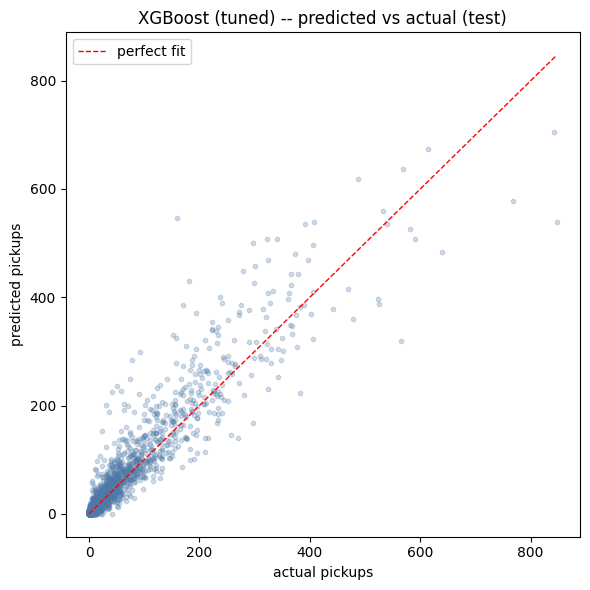

Saved results to the results/ folder


In [ ]:
# combine all model metrics into one comparison table
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.pivot_table(index='model', columns='split', values=['MAE', 'RMSE', 'R2']).round(4))

best_val_model = metrics_df[metrics_df['split'] == 'val'].sort_values('RMSE').iloc[0]['model']
best_test_model = metrics_df[metrics_df['split'] == 'test'].sort_values('RMSE').iloc[0]['model']

print('Best validation model:', best_val_model)
print('Best test model:', best_test_model)

# save metrics, tuning history, and best parameter choices
metrics_df.to_csv(RESULTS_DIR / 'tree_model_metrics.csv', index=False)

search_history_df = pd.concat([
    pd.DataFrame(rf_search_rows).assign(search='random_forest'),
    pd.DataFrame(xgb_search_rows).assign(search='xgboost'),
], ignore_index=True)
search_history_df.to_csv(RESULTS_DIR / 'tree_model_search_history.csv', index=False)

with open(RESULTS_DIR / 'tree_model_best_params.json', 'w') as f:
    json.dump({'random_forest': best_rf_params, 'xgboost': best_xgb_params}, f, indent=2)

# choose the better tuned tree model using validation RMSE
rf_val_rmse = metrics_df[(metrics_df['model'] == 'Random Forest (tuned)') & (metrics_df['split'] == 'val')]['RMSE'].iloc[0]
xgb_val_rmse = metrics_df[(metrics_df['model'] == 'XGBoost (tuned)') & (metrics_df['split'] == 'val')]['RMSE'].iloc[0]

if xgb_val_rmse < rf_val_rmse:
    best_tree_name = 'XGBoost (tuned)'
    best_tree_pred = xgb_tuned_test_pred
else:
    best_tree_name = 'Random Forest (tuned)'
    best_tree_pred = rf_tuned_test_pred

# save one actual-vs-predicted plot for the best tuned tree model
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_tree_pred, alpha=0.25, s=10, color='#4e79a7')
max_val = max(float(np.max(y_test)), float(np.max(best_tree_pred)))
ax.plot([0, max_val], [0, max_val], 'r--', lw=1, label='perfect fit')
ax.set_xlabel('actual pickups')
ax.set_ylabel('predicted pickups')
ax.set_title(f'{best_tree_name} -- predicted vs actual (test)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'best_tuned_tree_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved results to the results folder')
